# Notebook 12a — 3D Tetrahedral Sign Check (concept introduction)

This is the first half of the 3D 6-tet treatment. It introduces the geometry: how each voxel cube splits into 6 tetrahedra along a body diagonal, how each tet's signed volume is computed, why the per-tet sign flip is needed, and which tets are affected when one voxel's displacement changes.

**Read 12a first**, then continue to [12b — optimization process](12b_3d-tetrahedral-check_optimization.ipynb), which runs the SLSQP correction on synthetic 3D bowtie cases.

Companion to [01_vs-central-diff.ipynb](01_vs-central-diff.ipynb) (the 2D 2-triangle check this lifts to 3D).

In [1]:
import os, sys, time
sys.path.insert(0, os.path.abspath('../..'))

import numpy as np
import matplotlib.pyplot as plt
from mpl_toolkits.mplot3d import Axes3D  # noqa: F401  (registers 3d projection)
from scipy.optimize import minimize, NonlinearConstraint

from dvfopt import DEFAULT_PARAMS
from dvfopt.jacobian.numpy_jdet import _numpy_jdet_3d, jacobian_det3D
from dvfopt.core.objective import objective_euc

THRESHOLD = DEFAULT_PARAMS['threshold']
print(f'THRESHOLD = {THRESHOLD}')

THRESHOLD = 0.01


## Geometry — 6-tet decomposition

A voxel cell has 8 corners indexed by `(z, y, x)` offset:

```
v0 = (0,0,0)   v4 = (1,0,0)
v1 = (0,0,1)   v5 = (1,0,1)
v2 = (0,1,0)   v6 = (1,1,0)
v3 = (0,1,1)   v7 = (1,1,1)
```

The body diagonal `v0 → v7` has Hamming distance 3 in `(z,y,x)` bits, so there are `3! = 6` monotone edge paths from `v0` to `v7`. Each path defines a tetrahedron `(v0, A, B, v7)` where `A` and `B` are the two intermediate corners on the path. All 6 tets share the body diagonal as an edge.

| tet | path | A | B |
|----|----|----|----|
| T0 | x, y, z | v1 | v3 |
| T1 | x, z, y | v1 | v5 |
| T2 | y, x, z | v2 | v3 |
| T3 | y, z, x | v2 | v6 |
| T4 | z, x, y | v4 | v5 |
| T5 | z, y, x | v4 | v6 |

Half of these orderings are even permutations and half odd, so the raw scalar triple product `(b−a)·((c−a)×(d−a))` returns `+1` for some tets and `−1` for others on the unwarped reference cube. We compute the 6 unwarped signs once at notebook startup and apply a fixed per-tet `±1` flip vector so that valid (positive-Jacobian) cells always return strictly positive volumes for all 6 tets.

## Helpers

In [2]:
# 8 cube corners as (z, y, x) offsets, indexed v0..v7 with z*4 + y*2 + x.
CUBE_CORNERS = np.array([
    [0, 0, 0],  # v0
    [0, 0, 1],  # v1
    [0, 1, 0],  # v2
    [0, 1, 1],  # v3
    [1, 0, 0],  # v4
    [1, 0, 1],  # v5
    [1, 1, 0],  # v6
    [1, 1, 1],  # v7
], dtype=np.int8)

# 6-tet body-diagonal decomposition: each row is (v0, A, B, v7) for one of the
# 3! monotone paths from v0 to v7. See the markdown table above.
TET_INDICES = np.array([
    [0, 1, 3, 7],  # T0  path x, y, z
    [0, 1, 5, 7],  # T1  path x, z, y
    [0, 2, 3, 7],  # T2  path y, x, z
    [0, 2, 6, 7],  # T3  path y, z, x
    [0, 4, 5, 7],  # T4  path z, x, y
    [0, 4, 6, 7],  # T5  path z, y, x
], dtype=np.int8)


def warp_corners(phi):
    """Return warped (x, y, z) coordinates of every voxel.

    phi : ndarray, shape (3, D, H, W) with channels [dz, dy, dx].
    Returns ndarray, shape (D, H, W, 3) with last axis = (x, y, z).
    """
    D, H, W = phi.shape[1:]
    zz, yy, xx = np.mgrid[:D, :H, :W]
    dz, dy, dx = phi[0], phi[1], phi[2]
    return np.stack([xx + dx, yy + dy, zz + dz], axis=-1)

In [3]:
# Sanity: identity field warps to identity, shape is right.
phi0 = np.zeros((3, 4, 5, 6))
Wc = warp_corners(phi0)
assert Wc.shape == (4, 5, 6, 3)
assert np.allclose(Wc[2, 3, 4], [4, 3, 2])  # corner (z=2,y=3,x=4) -> (x=4,y=3,z=2)
print('warp_corners OK')

warp_corners OK


### Step 1 — start with one voxel cube

Before any decomposition, this is the object we're working with: one voxel cell of the deformation grid, with its 8 corners labeled `v_i` and tagged with their `(z, y, x)` offsets — exactly what's spelled out in the geometry markdown above. The walkthrough that follows splits this cube into 6 tetrahedra, computes a signed volume per tet, and shows how SLSQP uses those volumes as constraints.

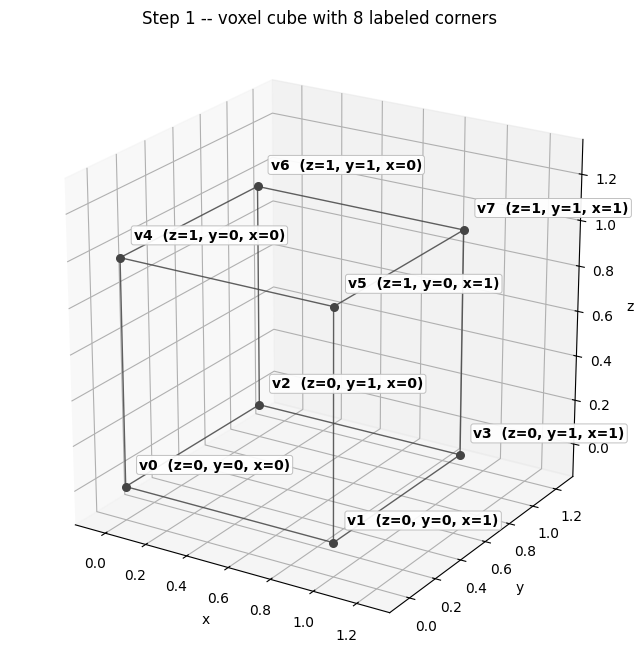

In [4]:
# Step 1 is self-contained: just draw the unit cube with labeled corners.
# (The helpers used by later steps come from the cube-decomposition cell below.)
from mpl_toolkits.mplot3d.art3d import Poly3DCollection  # used by later steps too

CUBE_EDGES = [
    (0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7),
]


def _xyz(c):
    return float(c[2]), float(c[1]), float(c[0])


fig = plt.figure(figsize=(7.5, 6.5), layout='constrained')
ax = fig.add_subplot(111, projection='3d')
for i, j in CUBE_EDGES:
    x0, y0, z0 = _xyz(CUBE_CORNERS[i])
    x1, y1, z1 = _xyz(CUBE_CORNERS[j])
    ax.plot([x0, x1], [y0, y1], [z0, z1], color='#444444', lw=1.0, alpha=0.85)
for i, c in enumerate(CUBE_CORNERS):
    x, y, z = _xyz(c)
    cz, cy, cx = int(c[0]), int(c[1]), int(c[2])
    label = "v" + str(i) + "  (z=" + str(cz) + ", y=" + str(cy) + ", x=" + str(cx) + ")"
    ax.text(x + 0.04, y + 0.04, z + 0.06, label,
            color='black', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.18', facecolor='white',
                      edgecolor='#bbbbbb', linewidth=0.7, alpha=0.92),
            ha='left', va='bottom')
    ax.scatter(x, y, z, color='#444444', s=30, zorder=10)
ax.set_xlim(-0.15, 1.35); ax.set_ylim(-0.15, 1.35); ax.set_zlim(-0.15, 1.35)
ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
ax.set_box_aspect((1, 1, 1))
ax.view_init(elev=22, azim=-58)
ax.set_title('Step 1 -- voxel cube with 8 labeled corners', fontsize=12)
plt.show()

### Visualizing the cube → 6-tet decomposition

The figure below makes the structure concrete:

- **Panel 1.** A single voxel cube with all 8 corners `v0..v7` labeled by their `(z, y, x)` offsets. The **red** edge is the body diagonal `v0 → v7` — every tet shares it.
- **Panels 2–7.** Each tet `T0..T5` drawn individually inside the cube outline. The 4 vertices are marked with dots; the **3 thick coloured edges** trace the monotone `(v0, A, B, v7)` path through cube edges; the **filled translucent volume** is the tet itself; the red diagonal is shown for context.
- **Panel 8.** All 6 tets stacked at low opacity. They share the body diagonal, have disjoint interiors, and their union is the whole cube — that is what makes this a valid decomposition.

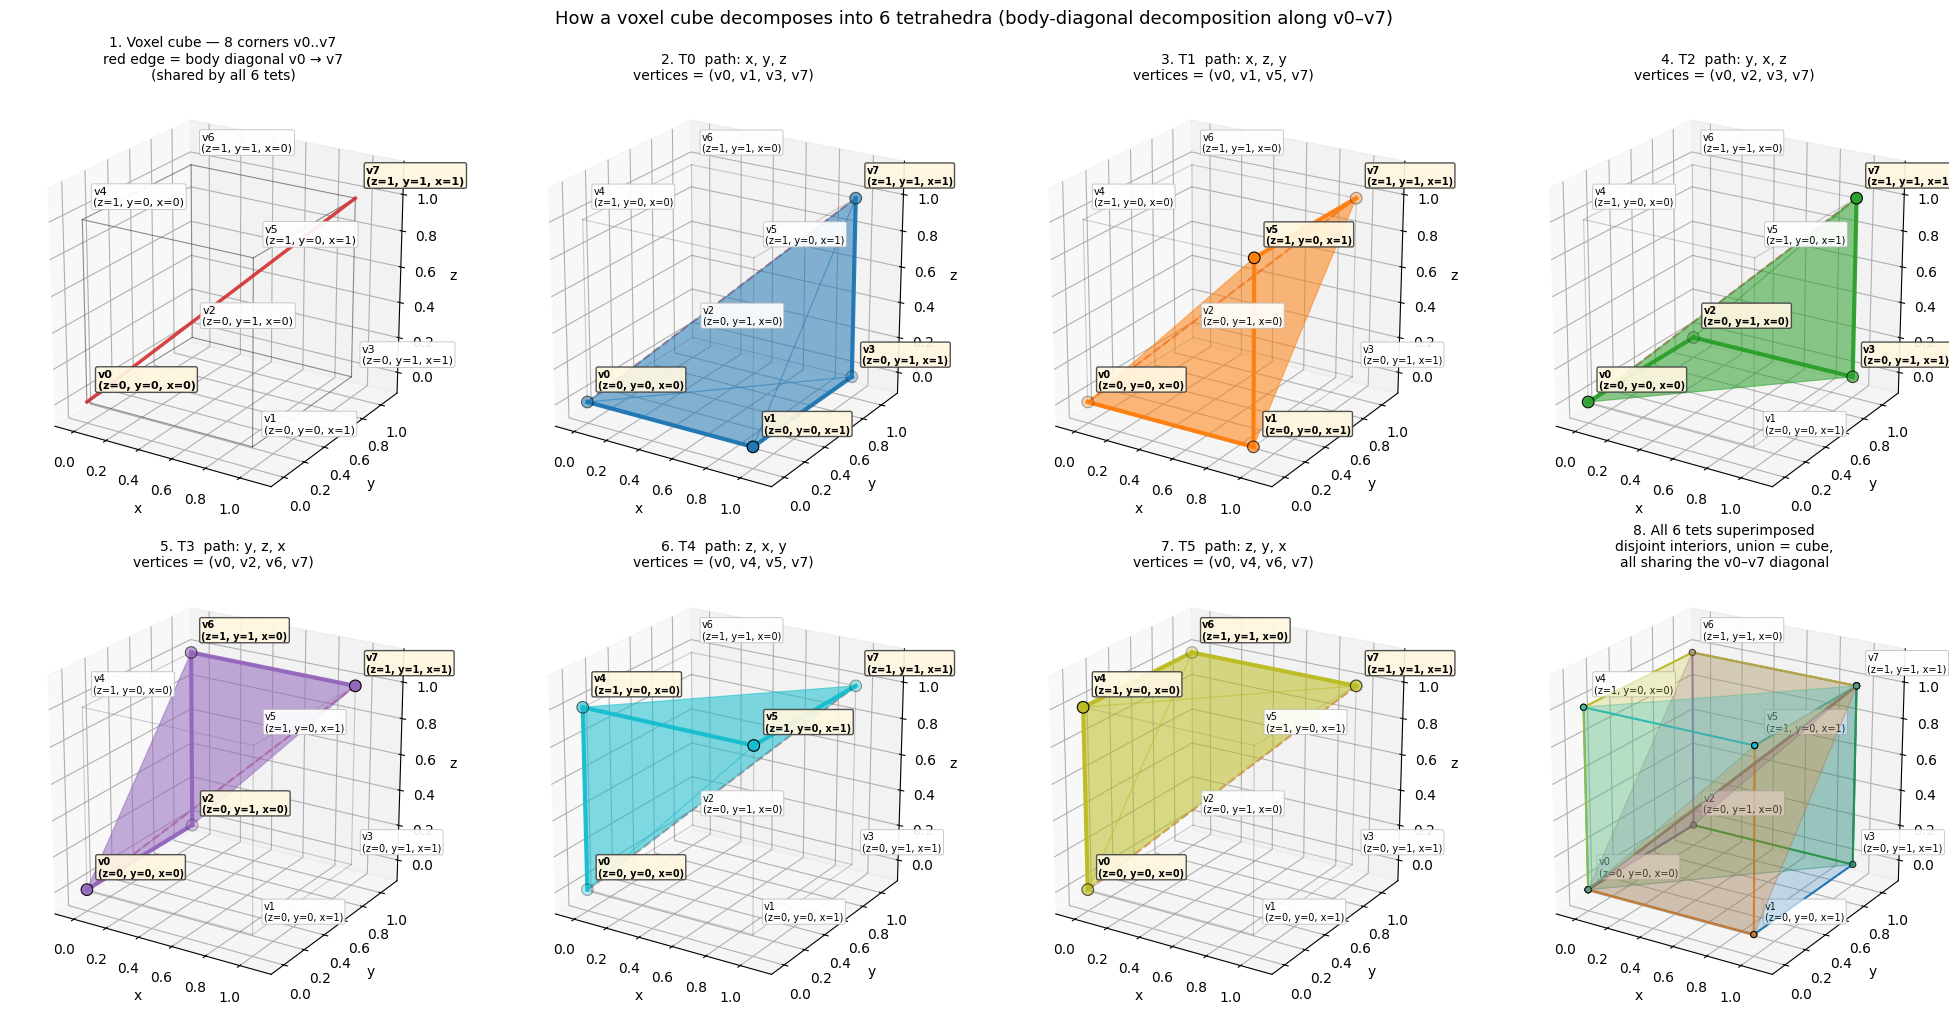

 tet  vertices                      path         V_signed     |V|
  T0  (v0,v1,v3,v7)                 x, y, z       +0.1667  0.1667
  T1  (v0,v1,v5,v7)                 x, z, y       -0.1667  0.1667
  T2  (v0,v2,v3,v7)                 y, x, z       -0.1667  0.1667
  T3  (v0,v2,v6,v7)                 y, z, x       +0.1667  0.1667
  T4  (v0,v4,v5,v7)                 z, x, y       +0.1667  0.1667
  T5  (v0,v4,v6,v7)                 z, y, x       -0.1667  0.1667

sum of |V_t| = 1.0000   (expected 1.0 = cube volume)
-> the 6 tets tile the unit cube with no overlap and no gap.


In [5]:
from mpl_toolkits.mplot3d.art3d import Poly3DCollection

# 12 edges of the unit cube (pairs of v_i indices).
CUBE_EDGES = [
    (0,1),(0,2),(0,4),(1,3),(1,5),(2,3),(2,6),(3,7),(4,5),(4,6),(5,7),(6,7),
]

# Distinct, colour-blind-friendly hues for T0..T5.
TET_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd', '#17becf', '#bcbd22']

# Path labels (which axis bit is flipped at each step v0 -> A -> B -> v7).
TET_PATHS = ['x, y, z', 'x, z, y', 'y, x, z', 'y, z, x', 'z, x, y', 'z, y, x']


def _xyz(corner_zyx):
    """Convert a (z, y, x) corner offset to (x, y, z) for matplotlib's 3D axes."""
    return float(corner_zyx[2]), float(corner_zyx[1]), float(corner_zyx[0])


def _draw_cube(ax, edge_alpha=0.6, label_corners=True, label_size=9,
               label_with_coords=True, highlight_vs=None):
    for i, j in CUBE_EDGES:
        x0, y0, z0 = _xyz(CUBE_CORNERS[i])
        x1, y1, z1 = _xyz(CUBE_CORNERS[j])
        ax.plot([x0, x1], [y0, y1], [z0, z1], color='#444444', lw=0.8, alpha=edge_alpha)
    if label_corners:
        for i, c in enumerate(CUBE_CORNERS):
            x, y, z = _xyz(c)
            cz, cy, cx = int(c[0]), int(c[1]), int(c[2])
            text = f'v{i}\n(z={cz}, y={cy}, x={cx})' if label_with_coords else f'v{i}'
            is_highlight = highlight_vs is not None and i in highlight_vs
            bbox = dict(boxstyle='round,pad=0.18',
                        facecolor='#fff7e0' if is_highlight else 'white',
                        edgecolor='#444444' if is_highlight else '#bbbbbb',
                        linewidth=1.0 if is_highlight else 0.6,
                        alpha=0.92)
            ax.text(x + 0.04, y + 0.04, z + 0.06, text,
                    color='black', fontsize=label_size,
                    fontweight='bold' if is_highlight else 'normal',
                    bbox=bbox, ha='left', va='bottom')


def _draw_diagonal(ax, color='#d32f2f', lw=2.5, alpha=0.9, dashed=False):
    x0, y0, z0 = _xyz(CUBE_CORNERS[0])
    x1, y1, z1 = _xyz(CUBE_CORNERS[7])
    ax.plot([x0, x1], [y0, y1], [z0, z1],
            color=color, lw=lw, alpha=alpha,
            linestyle='--' if dashed else '-')


def _draw_tet(ax, t, color, fill_alpha=0.32, path_lw=3.0, marker_size=70):
    """Draw tet T_t: filled volume + path edges + vertex markers."""
    inds = TET_INDICES[t]
    pts = np.array([_xyz(CUBE_CORNERS[i]) for i in inds])  # (4, 3)

    # Fill the 4 faces.
    faces = [
        [pts[0], pts[1], pts[2]],
        [pts[0], pts[1], pts[3]],
        [pts[0], pts[2], pts[3]],
        [pts[1], pts[2], pts[3]],
    ]
    poly = Poly3DCollection(faces, facecolor=color, alpha=fill_alpha,
                             edgecolor=color, linewidth=0.8)
    ax.add_collection3d(poly)

    # Highlight the (v0, A, B, v7) monotone path with thick coloured segments.
    for k in range(3):
        p, q = pts[k], pts[k + 1]
        ax.plot([p[0], q[0]], [p[1], q[1]], [p[2], q[2]],
                color=color, lw=path_lw, alpha=0.95)

    # Vertex dots.
    ax.scatter(pts[:, 0], pts[:, 1], pts[:, 2], color=color,
               s=marker_size, edgecolor='black', linewidth=0.8, zorder=10)


def _set_cube_view(ax, elev=22, azim=-58):
    ax.set_xlim(-0.12, 1.18); ax.set_ylim(-0.12, 1.18); ax.set_zlim(-0.12, 1.18)
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=elev, azim=azim)


fig = plt.figure(figsize=(20, 10), layout='constrained')

# Panel 1: labeled cube + body diagonal — emphasise the diagonal endpoints.
ax0 = fig.add_subplot(2, 4, 1, projection='3d')
_draw_cube(ax0, label_size=8, highlight_vs={0, 7})
_draw_diagonal(ax0)
_set_cube_view(ax0)
ax0.set_title('1. Voxel cube — 8 corners v0..v7\n'
              'red edge = body diagonal v0 → v7\n'
              '(shared by all 6 tets)', fontsize=10)

# Panels 2–7: each tet individually. Highlight that tet's 4 vertex labels.
for t in range(6):
    ax = fig.add_subplot(2, 4, t + 2, projection='3d')
    inds = TET_INDICES[t]
    _draw_cube(ax, edge_alpha=0.25, label_size=7, highlight_vs=set(inds))
    _draw_diagonal(ax, lw=1.6, alpha=0.55, dashed=True)
    _draw_tet(ax, t, TET_COLORS[t])
    _set_cube_view(ax)
    ax.set_title(f'{t + 2}. T{t}  path: {TET_PATHS[t]}\n'
                 f'vertices = (v{inds[0]}, v{inds[1]}, v{inds[2]}, v{inds[3]})',
                 fontsize=10)

# Panel 8: all 6 tets stacked.
ax_all = fig.add_subplot(2, 4, 8, projection='3d')
_draw_cube(ax_all, edge_alpha=0.55, label_size=7)
for t in range(6):
    _draw_tet(ax_all, t, TET_COLORS[t], fill_alpha=0.13, path_lw=1.5, marker_size=20)
_draw_diagonal(ax_all, lw=2.0)
_set_cube_view(ax_all)
ax_all.set_title('8. All 6 tets superimposed\n'
                 'disjoint interiors, union = cube,\n'
                 'all sharing the v0–v7 diagonal', fontsize=10)

plt.suptitle('How a voxel cube decomposes into 6 tetrahedra '
             '(body-diagonal decomposition along v0–v7)', fontsize=13)
plt.show()


# Sanity: the 6 tets' unsigned volumes (raw scalar triple products /6) sum to 1.
# This proves they tile the cube without overlap or gap. Their *signed* volumes
# alternate +1/6 and -1/6 by the parity of the path orderings (which is exactly
# what TET_SIGN_FLIP corrects for downstream).
def _tet_volume_signed(pts_xyz):
    a, b, c, d = pts_xyz
    return float(np.dot(b - a, np.cross(c - a, d - a))) / 6.0


total_unsigned = 0.0
print(f'{"tet":>4s}  {"vertices":<28s}  {"path":<10s}  {"V_signed":>9s}  {"|V|":>6s}')
for t in range(6):
    inds = TET_INDICES[t]
    pts = np.array([_xyz(CUBE_CORNERS[i]) for i in inds])
    v_signed = _tet_volume_signed(pts)
    total_unsigned += abs(v_signed)
    print(f'  T{t}  {"(v" + ",v".join(str(i) for i in inds) + ")":<28s}  '
          f'{TET_PATHS[t]:<10s}  {v_signed:+9.4f}  {abs(v_signed):>6.4f}')
print(f'\nsum of |V_t| = {total_unsigned:.4f}   (expected 1.0 = cube volume)')
print('-> the 6 tets tile the unit cube with no overlap and no gap.')

In [6]:
def _tet_volumes_unsigned(corners):
    """Compute the 6 raw tet scalar triple products per cell.

    Output shape: (6, D-1, H-1, W-1). Not yet divided by 6 and not yet
    sign-flipped (some entries are negative on the reference cube).
    """
    cell_corners = []
    for (oz, oy, ox) in CUBE_CORNERS:
        cell_corners.append(corners[oz:corners.shape[0] - 1 + oz,
                                     oy:corners.shape[1] - 1 + oy,
                                     ox:corners.shape[2] - 1 + ox])
    cell_corners = np.stack(cell_corners, axis=0)  # (8, D-1, H-1, W-1, 3)

    raw = np.empty((6,) + cell_corners.shape[1:-1], dtype=corners.dtype)
    for ti, (ia, ib, ic, id_) in enumerate(TET_INDICES):
        a = cell_corners[ia]; b = cell_corners[ib]
        c = cell_corners[ic]; d = cell_corners[id_]
        ab = b - a; ac = c - a; ad = d - a
        cx = ac[..., 1] * ad[..., 2] - ac[..., 2] * ad[..., 1]
        cy = ac[..., 2] * ad[..., 0] - ac[..., 0] * ad[..., 2]
        cz = ac[..., 0] * ad[..., 1] - ac[..., 1] * ad[..., 0]
        raw[ti] = ab[..., 0] * cx + ab[..., 1] * cy + ab[..., 2] * cz
    return raw


def _calibrate_sign_flip():
    """One-time per-tet ±1 flip so that the unwarped reference cube returns
    strictly positive volumes for all 6 tets."""
    phi_id = np.zeros((3, 2, 2, 2))
    raw_id = _tet_volumes_unsigned(warp_corners(phi_id))  # (6, 1, 1, 1)
    flip = np.sign(raw_id[:, 0, 0, 0]).astype(np.float64)
    if np.any(flip == 0):
        raise RuntimeError(f'Degenerate identity-field tet volumes: {raw_id.ravel()}')
    return flip


TET_SIGN_FLIP = _calibrate_sign_flip()
print(f'TET_SIGN_FLIP = {TET_SIGN_FLIP}')


def tet_signed_volumes(phi):
    """Per-cell signed volumes of the 6-tet decomposition.

    phi : ndarray, shape (3, D, H, W) with channels [dz, dy, dx].
    Returns ndarray, shape (6, D-1, H-1, W-1). Positive = valid,
    zero = degenerate, negative = flip.
    """
    raw = _tet_volumes_unsigned(warp_corners(phi))
    return TET_SIGN_FLIP[:, None, None, None] * raw / 6.0


def tet_min_per_cell(phi):
    """Worst-of-6 signed volume per cell. Shape (D-1, H-1, W-1)."""
    return tet_signed_volumes(phi).min(axis=0)


def tet_count_negatives(phi):
    """Count of (tet, cell) pairs with signed volume <= 0."""
    return int((tet_signed_volumes(phi) <= 0).sum())

TET_SIGN_FLIP = [ 1. -1. -1.  1.  1. -1.]


In [7]:
# Sanity: identity field gives positive equal volumes for all 6 tets.
phi0 = np.zeros((3, 5, 5, 5))
V = tet_signed_volumes(phi0)
assert V.shape == (6, 4, 4, 4)
assert np.allclose(V, 1.0 / 6.0), f'Expected all 1/6, got min/max = {V.min()}, {V.max()}'

# Sanity: a uniform translation leaves all volumes unchanged.
phi_t = np.zeros((3, 5, 5, 5))
phi_t[0] += 0.3; phi_t[1] -= 0.7; phi_t[2] += 1.4
V_t = tet_signed_volumes(phi_t)
assert np.allclose(V_t, 1.0 / 6.0)

# Sanity: a uniform 2x scaling gives 2^3 / 6 per tet.
phi_s = np.zeros((3, 5, 5, 5))
zz, yy, xx = np.mgrid[:5, :5, :5]
phi_s[0] = zz; phi_s[1] = yy; phi_s[2] = xx  # corners (z,y,x) -> (2z,2y,2x)
V_s = tet_signed_volumes(phi_s)
assert np.allclose(V_s, 8.0 / 6.0), f'Expected 8/6, got min={V_s.min()}, max={V_s.max()}'

# Sanity: a single-voxel inversion folds a cell.
phi_fold = np.zeros((3, 3, 3, 3))
phi_fold[2, 1, 1, 1] = -2.5  # large -dx pulls centre voxel past its left neighbour
V_f = tet_signed_volumes(phi_fold)
assert (V_f <= 0).any(), 'Expected at least one negative tet for the inversion test'

print(f'Identity volume       : {V[0,0,0,0]:.6f}  (expected 1/6 = {1/6:.6f})')
print(f'Uniform 2x scaling    : {V_s[0,0,0,0]:.6f}  (expected 8/6 = {8/6:.6f})')
print(f'Inversion test n_neg  : {int((V_f <= 0).sum())}')
print('tet_signed_volumes OK')

Identity volume       : 0.166667  (expected 1/6 = 0.166667)
Uniform 2x scaling    : 1.333333  (expected 8/6 = 1.333333)
Inversion test n_neg  : 6
tet_signed_volumes OK


### Step 2 — compute the signed volume of one tetrahedron

Every tet has 4 vertices we label `(a, b, c, d)`, where `a = v0`, `b = v_A`, `c = v_B`, `d = v7` for the canonical `(v0, A, B, v7)` path ordering. The signed volume is

$$
V \;=\; \frac{1}{6}\;\bigl(\mathbf{b}-\mathbf{a}\bigr) \,\cdot\, \bigl[(\mathbf{c}-\mathbf{a})\times(\mathbf{d}-\mathbf{a})\bigr].
$$

The plot below shows tet **T0** with its three edge vectors `b−a`, `c−a`, `d−a` drawn from `a` in distinct colours. The right panel does the same for **T1** to illustrate that some tets' raw scalar triple product comes out **negative** before the per-tet sign flip — a consequence of the path ordering being an odd permutation of the cube's vertices.

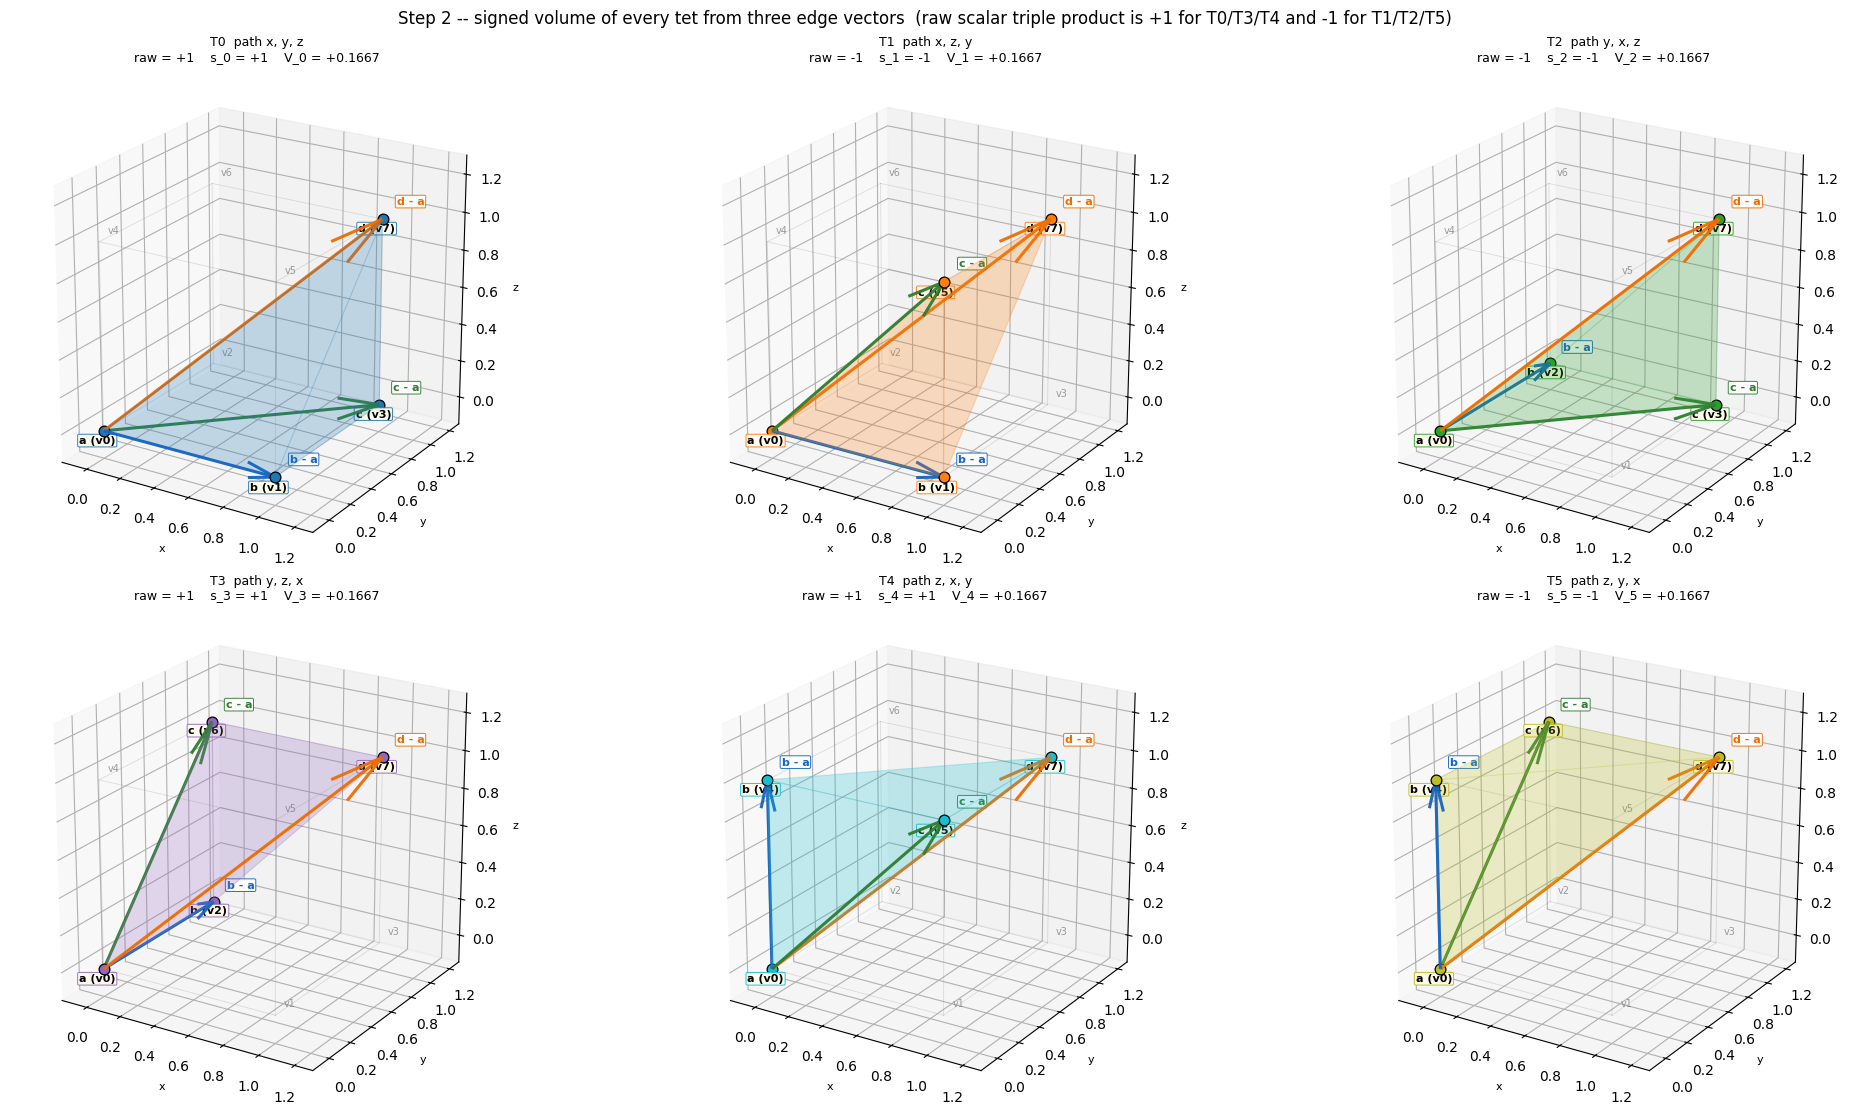

In [8]:
def _tet_compute(t):
    inds = TET_INDICES[t]
    pts = np.array([_xyz(CUBE_CORNERS[i]) for i in inds])  # (4, 3) in (x, y, z)
    a, b, c, d = pts
    ab = b - a; ac = c - a; ad = d - a
    n = np.cross(ac, ad)
    raw = float(np.dot(ab, n))
    s = float(TET_SIGN_FLIP[t])
    V = s * raw / 6.0
    return raw, s, V, pts


VEC_COLORS = ('#1565c0', '#2e7d32', '#ef6c00')  # b-a, c-a, d-a respectively


def _draw_tet_with_vectors(ax, t):
    raw, s, V, pts = _tet_compute(t)
    a, b, c, d = pts
    color = TET_COLORS[t]
    inds = TET_INDICES[t]

    # Faint cube outline + small unboxed vertex labels for context.
    for i, j in CUBE_EDGES:
        x0, y0, z0 = _xyz(CUBE_CORNERS[i])
        x1, y1, z1 = _xyz(CUBE_CORNERS[j])
        ax.plot([x0, x1], [y0, y1], [z0, z1], color='#888888', lw=0.6, alpha=0.25)
    for i, cube_c in enumerate(CUBE_CORNERS):
        xx, yy, zz = _xyz(cube_c)
        if i not in set(inds):
            ax.text(xx + 0.03, yy + 0.03, zz + 0.04, "v" + str(i),
                    color='#888888', fontsize=7, alpha=0.85)

    # Tet body (translucent).
    faces = [
        [pts[0], pts[1], pts[2]],
        [pts[0], pts[1], pts[3]],
        [pts[0], pts[2], pts[3]],
        [pts[1], pts[2], pts[3]],
    ]
    ax.add_collection3d(Poly3DCollection(
        faces, facecolor=color, alpha=0.13,
        edgecolor=color, linewidth=0.8))

    # Three edge vectors b-a, c-a, d-a from a.
    names = ['b - a', 'c - a', 'd - a']
    for q, name, vc in zip([b, c, d], names, VEC_COLORS):
        v = q - a
        ax.quiver(a[0], a[1], a[2], v[0], v[1], v[2],
                  color=vc, lw=2.2, arrow_length_ratio=0.16, alpha=0.95)
        # Label slightly offset from arrowhead, with a small white box.
        ax.text(q[0] + 0.05, q[1] + 0.05, q[2] + 0.07, name,
                color=vc, fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='white',
                          edgecolor=vc, linewidth=0.7, alpha=0.92))

    # Tet vertex role labels (a/b/c/d <-> v_i).
    role_labels = ['a (v' + str(inds[0]) + ')', 'b (v' + str(inds[1]) + ')',
                   'c (v' + str(inds[2]) + ')', 'd (v' + str(inds[3]) + ')']
    for pt, lbl in zip(pts, role_labels):
        ax.scatter(pt[0], pt[1], pt[2], color=color, s=60,
                   edgecolor='black', linewidth=0.9, zorder=10)
        ax.text(pt[0] - 0.08, pt[1] - 0.10, pt[2] - 0.05, lbl,
                color='black', fontsize=8, fontweight='bold',
                bbox=dict(boxstyle='round,pad=0.12', facecolor='#fffceb',
                          edgecolor=color, linewidth=0.7, alpha=0.92))

    ax.set_xlim(-0.15, 1.30); ax.set_ylim(-0.15, 1.30); ax.set_zlim(-0.15, 1.30)
    ax.set_xlabel('x', fontsize=8); ax.set_ylabel('y', fontsize=8); ax.set_zlabel('z', fontsize=8)
    ax.set_box_aspect((1, 1, 1))
    ax.view_init(elev=22, azim=-58)

    title = ("T" + str(t) + "  path " + TET_PATHS[t] + chr(10) +
             "raw = " + ("+1" if raw > 0 else "-1") +
             "    s_" + str(t) + " = " + ("+1" if s > 0 else "-1") +
             "    V_" + str(t) + " = " + format(V, "+.4f"))
    ax.set_title(title, fontsize=9)


fig = plt.figure(figsize=(20, 11), layout='constrained')
for t in range(6):
    ax = fig.add_subplot(2, 3, t + 1, projection='3d')
    _draw_tet_with_vectors(ax, t)

plt.suptitle("Step 2 -- signed volume of every tet from three edge vectors  "
             "(raw scalar triple product is +1 for T0/T3/T4 and -1 for T1/T2/T5)",
             fontsize=12)
plt.show()

### Step 3 — calibrate the sign flip across all 6 tets

Doing the same scalar-triple-product computation on every tet of the unwarped reference cube gives `+1` for three of them (T0, T3, T4 — even permutations of the cube's vertices) and `−1` for the other three (T1, T2, T5 — odd permutations). To make a uniform constraint `V_t \u2265 \u03c4` work for every tet, we apply a fixed `s_t \u2208 {\u00b11}` per tet so the unwarped cube returns `+1/6` for *all* six. That `s` vector is `TET_SIGN_FLIP`, computed once at startup by `_calibrate_sign_flip`.

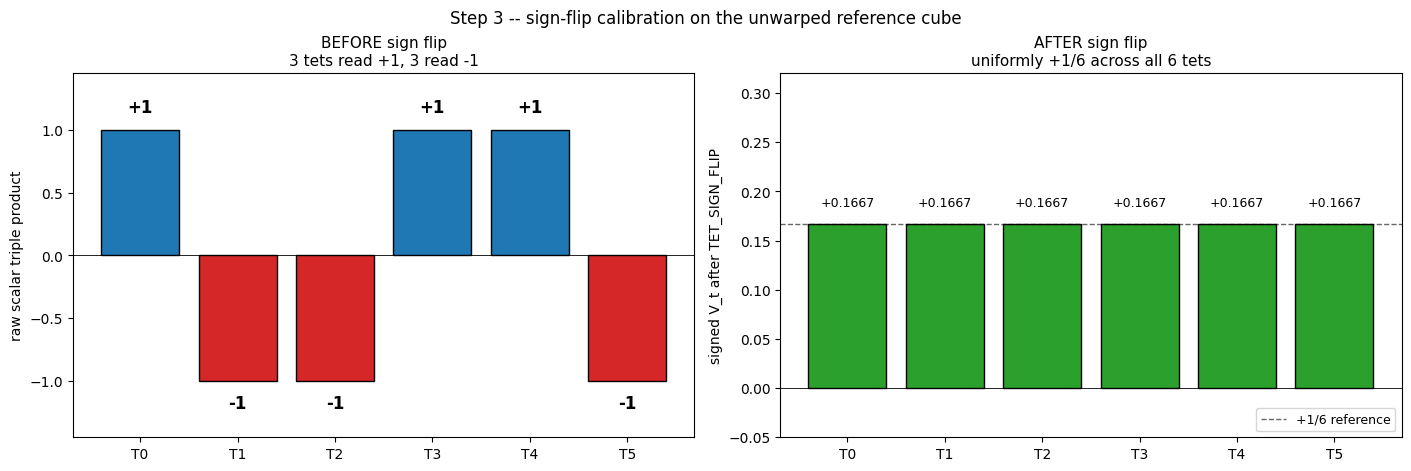

TET_SIGN_FLIP = [1.0, -1.0, -1.0, 1.0, 1.0, -1.0]


In [9]:
raws = np.array([_tet_compute(t)[0] for t in range(6)])
flipped = TET_SIGN_FLIP * raws / 6.0

fig, axes = plt.subplots(1, 2, figsize=(14, 4.6), layout='constrained')

# LEFT panel: raw scalar triple products (range +/-1).
bar_colors = ['#1f77b4' if r > 0 else '#d62728' for r in raws]
axes[0].bar(range(6), raws, color=bar_colors, edgecolor='black')
axes[0].axhline(0, color='black', lw=0.6)
axes[0].set_xticks(range(6))
axes[0].set_xticklabels(['T' + str(i) for i in range(6)])
axes[0].set_ylabel('raw scalar triple product')
axes[0].set_ylim(-1.45, 1.45)
axes[0].set_title('BEFORE sign flip\n3 tets read +1, 3 read -1', fontsize=11)
for i, r in enumerate(raws):
    # Place value labels well clear of the bar tops (no overlap with title).
    axes[0].text(i, r + (0.18 if r > 0 else -0.18),
                 ('+1' if r > 0 else '-1'),
                 ha='center', va='center', fontsize=12, fontweight='bold')

# RIGHT panel: sign-flipped values (all +1/6 ~= 0.1667).
axes[1].bar(range(6), flipped, color='#2ca02c', edgecolor='black')
axes[1].axhline(0, color='black', lw=0.6)
axes[1].axhline(1 / 6, color='black', linestyle='--', lw=1.0, alpha=0.6,
                label='+1/6 reference')
axes[1].set_xticks(range(6))
axes[1].set_xticklabels(['T' + str(i) for i in range(6)])
axes[1].set_ylabel('signed V_t after TET_SIGN_FLIP')
axes[1].set_ylim(-0.05, 0.32)
axes[1].set_title('AFTER sign flip\nuniformly +1/6 across all 6 tets', fontsize=11)
axes[1].legend(loc='lower right', fontsize=9)
for i, v in enumerate(flipped):
    axes[1].text(i, v + 0.022, format(v, '+.4f'),
                 ha='center', va='center', fontsize=9)

plt.suptitle('Step 3 -- sign-flip calibration on the unwarped reference cube',
             fontsize=12)
plt.show()

print('TET_SIGN_FLIP = ' + str(TET_SIGN_FLIP.tolist()))

### Vertex influence — which tets does adjusting one voxel affect?

When SLSQP nudges a single voxel's displacement `(dz[v], dy[v], dx[v])`, the only tet volumes whose value changes are the ones that have that voxel as one of their 4 corners. Every other constraint in the `6 \u00b7 (D\u22121)(H\u22121)(W\u22121)`-long vector is unchanged.

For an **interior** grid vertex (away from the boundary), the voxel is a corner of up to 8 adjacent cells. In each cell it occupies one of the 8 local positions `v0..v7`:

- as `v0` or `v7` (in 1 cell each on average): part of all 6 tets in that cell.
- as `v1, v2, v3, v4, v5,` or `v6` (in 1 cell each): part of 2 tets in that cell.

Total: `2 \u00d7 6 + 6 \u00d7 2 = 24` tets touch every interior vertex. The figure below makes this concrete on a 3\u00d73\u00d73 voxel grid (= 2\u00d72\u00d72 = 8 cells around the central vertex). The focal vertex sits at `(z=1, y=1, x=1)`; we colour every tet that has it as a corner.

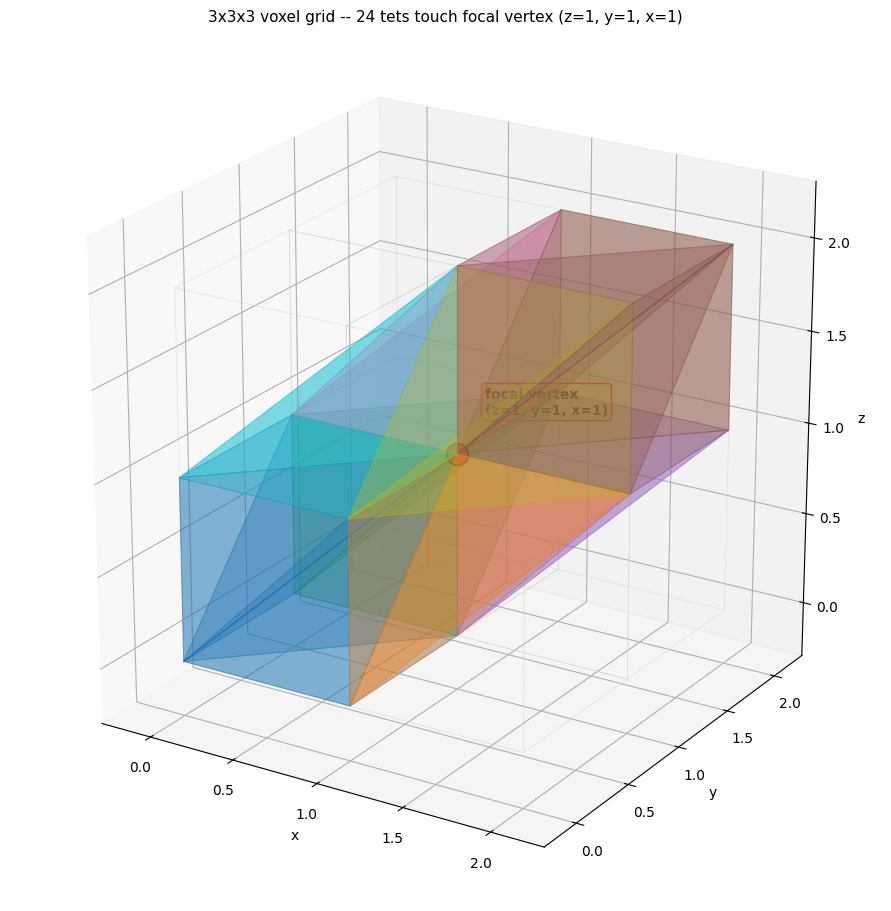

Tets touching vertex (z=1, y=1, x=1):  24 total across 8 cells
  cell (cz=0, cy=0, cx=0)   focal = v7   6 tets
  cell (cz=0, cy=0, cx=1)   focal = v6   2 tets
  cell (cz=0, cy=1, cx=0)   focal = v5   2 tets
  cell (cz=0, cy=1, cx=1)   focal = v4   2 tets
  cell (cz=1, cy=0, cx=0)   focal = v3   2 tets
  cell (cz=1, cy=0, cx=1)   focal = v2   2 tets
  cell (cz=1, cy=1, cx=0)   focal = v1   2 tets
  cell (cz=1, cy=1, cx=1)   focal = v0   6 tets


In [10]:
import plotly.graph_objects as go


def tets_touching_vertex(z0, y0, x0, grid_shape):
    """For vertex (z0, y0, x0) in a grid of shape (D, H, W), return a list of
    dicts, one per tet that has the vertex as a corner.
    """
    D, H, W = grid_shape
    out = []
    for dcz in (-1, 0):
        for dcy in (-1, 0):
            for dcx in (-1, 0):
                cz, cy, cx = z0 + dcz, y0 + dcy, x0 + dcx
                if cz < 0 or cy < 0 or cx < 0:
                    continue
                if cz >= D - 1 or cy >= H - 1 or cx >= W - 1:
                    continue
                local = (z0 - cz, y0 - cy, x0 - cx)
                focal_local = None
                for vi, c in enumerate(CUBE_CORNERS):
                    if (int(c[0]), int(c[1]), int(c[2])) == local:
                        focal_local = vi
                        break
                for t, inds in enumerate(TET_INDICES):
                    if focal_local in inds:
                        out.append({
                            'cell': (cz, cy, cx),
                            'tet': int(t),
                            'local_inds': tuple(int(i) for i in inds),
                            'focal_local': int(focal_local),
                        })
    return out


def _draw_grid_skeleton(ax, grid_shape, color='#cfcfcf', lw=0.5, alpha=0.55):
    D, H, W = grid_shape
    for cz in range(D - 1):
        for cy in range(H - 1):
            for cx in range(W - 1):
                for i, j in CUBE_EDGES:
                    p_i = CUBE_CORNERS[i]; p_j = CUBE_CORNERS[j]
                    x0, y0, z0 = cx + p_i[2], cy + p_i[1], cz + p_i[0]
                    x1, y1, z1 = cx + p_j[2], cy + p_j[1], cz + p_j[0]
                    ax.plot([x0, x1], [y0, y1], [z0, z1],
                            color=color, lw=lw, alpha=alpha)


def plot_vertex_tets_static(z0, y0, x0, grid_shape=(3, 3, 3)):
    """Static matplotlib snapshot — colour-grouped by parent cell."""
    D, H, W = grid_shape
    tets = tets_touching_vertex(z0, y0, x0, grid_shape)
    by_cell = {}
    for t in tets:
        by_cell.setdefault(t['cell'], []).append(t)

    fig = plt.figure(figsize=(11, 9), layout='constrained')
    ax = fig.add_subplot(111, projection='3d')
    _draw_grid_skeleton(ax, grid_shape)
    cell_colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd',
                   '#17becf', '#bcbd22', '#e377c2', '#8c564b']
    color_for = {cell: cell_colors[k % len(cell_colors)]
                 for k, cell in enumerate(by_cell)}
    for t in tets:
        cz, cy, cx = t['cell']
        inds = t['local_inds']
        pts = []
        for vi in inds:
            cv = CUBE_CORNERS[vi]
            pts.append((cx + cv[2], cy + cv[1], cz + cv[0]))
        pts = np.array(pts, dtype=float)
        col = color_for[t['cell']]
        faces = [
            [pts[0], pts[1], pts[2]],
            [pts[0], pts[1], pts[3]],
            [pts[0], pts[2], pts[3]],
            [pts[1], pts[2], pts[3]],
        ]
        ax.add_collection3d(Poly3DCollection(
            faces, facecolor=col, alpha=0.18,
            edgecolor=col, linewidth=0.7))
    ax.scatter([x0], [y0], [z0], color='red', s=240,
               edgecolor='black', linewidth=1.5, zorder=20)
    ax.text(x0 + 0.10, y0 + 0.10, z0 + 0.20,
            'focal vertex\n(z=' + str(z0) + ', y=' + str(y0) + ', x=' + str(x0) + ')',
            color='black', fontsize=10, fontweight='bold',
            bbox=dict(boxstyle='round,pad=0.25', facecolor='#ffeeaa',
                      edgecolor='red', linewidth=1.0, alpha=0.95))
    ax.set_xlabel('x'); ax.set_ylabel('y'); ax.set_zlabel('z')
    ax.set_xlim(-0.3, W - 0.7); ax.set_ylim(-0.3, H - 0.7); ax.set_zlim(-0.3, D - 0.7)
    ax.set_box_aspect((W, H, D))
    ax.view_init(elev=22, azim=-58)
    ax.set_title(
        '3x3x3 voxel grid -- ' + str(len(tets)) + ' tets touch focal vertex (z=' +
        str(z0) + ', y=' + str(y0) + ', x=' + str(x0) + ')',
        fontsize=11)
    plt.show()

    print('Tets touching vertex (z=' + str(z0) + ', y=' + str(y0) + ', x=' + str(x0) +
          '):  ' + str(len(tets)) + ' total across ' + str(len(by_cell)) + ' cells')
    for cell, ts in sorted(by_cell.items()):
        cz, cy, cx = cell
        local = ts[0]['focal_local']
        print('  cell (cz=' + str(cz) + ', cy=' + str(cy) + ', cx=' + str(cx) +
              ')   focal = v' + str(local) + '   ' + str(len(ts)) + ' tets')


def plot_vertex_tets_interactive(z0, y0, x0, grid_shape=(3, 3, 3)):
    """Plotly version: every tet is a Mesh3d body with hover info; the cube
    skeleton is drawn underneath; the focal vertex pops as a big red sphere.

    Each tet trace is in its own legend group keyed by parent cell — click a
    legend entry to toggle that cell's tets on/off and visually verify they
    don't overlap with any other cell's tets.
    """
    D, H, W = grid_shape
    tets = tets_touching_vertex(z0, y0, x0, grid_shape)

    fig = go.Figure()

    # Skeleton (single trace, NaN-separated).
    skel_x, skel_y, skel_z = [], [], []
    for cz in range(D - 1):
        for cy in range(H - 1):
            for cx in range(W - 1):
                for i, j in CUBE_EDGES:
                    pi = CUBE_CORNERS[i]; pj = CUBE_CORNERS[j]
                    skel_x += [cx + pi[2], cx + pj[2], np.nan]
                    skel_y += [cy + pi[1], cy + pj[1], np.nan]
                    skel_z += [cz + pi[0], cz + pj[0], np.nan]
    fig.add_trace(go.Scatter3d(
        x=skel_x, y=skel_y, z=skel_z, mode='lines',
        line=dict(color='#bbbbbb', width=2),
        name='cell skeleton', hoverinfo='skip',
    ))

    PLOTLY_CELL_COLORS = ['#1f77b4', '#ff7f0e', '#2ca02c', '#9467bd',
                          '#17becf', '#bcbd22', '#e377c2', '#8c564b']
    by_cell = {}
    for t in tets:
        by_cell.setdefault(t['cell'], []).append(t)

    for k, (cell, cell_tets) in enumerate(sorted(by_cell.items())):
        cz, cy, cx = cell
        color = PLOTLY_CELL_COLORS[k % len(PLOTLY_CELL_COLORS)]
        for t in cell_tets:
            inds = t['local_inds']
            pts = []
            for vi in inds:
                cv = CUBE_CORNERS[vi]
                pts.append([cx + cv[2], cy + cv[1], cz + cv[0]])
            pts = np.array(pts, dtype=float)
            # Mesh3d wants vertex coords + triangle face indices.
            tri_i = [0, 0, 0, 1]
            tri_j = [1, 1, 2, 2]
            tri_k = [2, 3, 3, 3]
            fig.add_trace(go.Mesh3d(
                x=pts[:, 0], y=pts[:, 1], z=pts[:, 2],
                i=tri_i, j=tri_j, k=tri_k,
                color=color, opacity=0.30,
                flatshading=True,
                name='cell (cz=' + str(cz) + ', cy=' + str(cy) + ', cx=' + str(cx) +
                     ') -- T' + str(t['tet']),
                hovertemplate=(
                    '<b>cell (cz=' + str(cz) + ', cy=' + str(cy) + ', cx=' + str(cx) + ')</b><br>'
                    'tet T' + str(t['tet']) + '  '
                    '(focal vertex = v' + str(t['focal_local']) + ' of this cell)<br>'
                    'vertices = (v' + ', v'.join(str(i) for i in inds) + ')'
                    '<extra></extra>'
                ),
                legendgroup='cell_' + str(cell),
                legendgrouptitle_text='cell ' + str(cell),
                showlegend=(t is cell_tets[0]),
            ))

    # Focal vertex.
    fig.add_trace(go.Scatter3d(
        x=[x0], y=[y0], z=[z0], mode='markers+text',
        marker=dict(size=11, color='red', line=dict(color='black', width=1.5)),
        text=['focal'], textposition='top center',
        textfont=dict(size=12, color='red', family='Arial Black'),
        name='focal vertex (z=' + str(z0) + ', y=' + str(y0) + ', x=' + str(x0) + ')',
        hovertemplate=('focal vertex (z=' + str(z0) + ', y=' + str(y0) + ', x=' + str(x0) + ')'
                       '<extra></extra>'),
    ))

    fig.update_layout(
        title=('Interactive: ' + str(len(tets)) + ' tets touch the focal vertex (z=' +
               str(z0) + ', y=' + str(y0) + ', x=' + str(x0) + ')<br>'
               '<sup>hover any tet for cell + tet info; click legend entries to isolate'
               '/hide individual cells</sup>'),
        scene=dict(xaxis_title='x', yaxis_title='y', zaxis_title='z',
                   aspectmode='cube'),
        height=700, margin=dict(l=0, r=0, b=0, t=60),
        legend=dict(groupclick='toggleitem'),
    )
    fig.show()


# Static matplotlib snapshot first.
plot_vertex_tets_static(z0=1, y0=1, x0=1, grid_shape=(3, 3, 3))

# Then the interactive plotly version.
plot_vertex_tets_interactive(z0=1, y0=1, x0=1, grid_shape=(3, 3, 3))

## Where to next

You now have the geometry: the body-diagonal 6-tet decomposition, the per-tet signed-volume formula `V = (s_t / 6) · (b−a) · ((c−a) × (d−a))`, the calibrated `TET_SIGN_FLIP` vector, and the vertex-influence pattern that lets you read off which tets a single voxel's displacement participates in.

Continue to **[12b — optimization process](12b_3d-tetrahedral-check_optimization.ipynb)** to see how this constraint set is fed to SLSQP (under an L1 objective) to correct synthetic 3D bowtie folds, with interactive 3D inspection of the before / after fields.